# Neuroscience-Informed Multi-Channel CNN

This notebook augments the baseline 12-channel model with **5 neuron-specific channels** derived from classical neuroscience:

| New channel | What it encodes | Why it helps |
|---|---|---|
| `rf_luminance` | Mean luminance **inside the neuron's RF** per frame | Global luminance is dominated by the full screen; local is the actual drive |
| `rf_contrast` | Pixel std **inside the RF** per frame | Contrast sensitivity varies by layer (L4 > L2/3 ≈ L5) |
| `rf_motion` | Frame-to-frame change **inside the RF** | Local motion energy at the RF — more relevant than global motion |
| `gabor_preferred` | Gabor energy at **preferred orientation** at RF location | Direct measure of stimulus alignment to the neuron's tuning |
| `gabor_orthogonal` | Gabor energy at **orthogonal orientation** at RF | Provides a baseline; ratio pref/orth encodes selectivity |

Since the structural metadata has no precomputed RF / tuning columns, all estimates come from the **Spike-Triggered Average (STA)** computed on the functional data.

**STA → RF & orientation pipeline:**
```
All trials for neuron n  →  STA image (64×64)
                         →  RF center (y_frac, x_frac)  +  RF size
                         →  Preferred orientation (0–180°)
```

**Total channels: 17** (12 original + 5 new).  
Architecture and training loop are identical to `CNN_multichannel.ipynb` (ShallowCNN).

In [7]:
%reload_ext autoreload
%autoreload 2

import sys, os, warnings, importlib, subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.ndimage import gaussian_filter, zoom
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Workspace root ─────────────────────────────────────────────────────────────
def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root.')

ROOT = _find_root()
for _d in [str(ROOT), str(Path('..').resolve())]:
    if _d not in sys.path:
        sys.path.insert(0, _d)

print(f'Workspace root: {ROOT}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE


In [8]:
# ── Global constants ───────────────────────────────────────────────────────────
TARGET_LEN          = 300     # resampled time-series length (frames)
MIN_TRACE_LEN       = 60      # minimum raw trace length to include a neuron
MAX_TRIALS_DATASET  = 8       # trials per scan used for the dataset sample
EXCLUDE_LAYERS      = {'L1'}  # too few samples to model

# STA settings
STA_SIZE            = 64      # spatial resolution for STA computation (pixels)
STA_LAG             = 1       # frames to shift response back (visual latency proxy)
MIN_STA_QUALITY     = 0.8     # min peak/noise ratio — below this use default RF

# Default tuning used when STA quality is too low
DEFAULT_RF_Y_FRAC   = 0.50    # RF centre y (fraction of clip height)
DEFAULT_RF_X_FRAC   = 0.50    # RF centre x (fraction of clip width)
DEFAULT_RF_SIZE_FRAC= 0.18    # RF radius (fraction of min clip dim)
DEFAULT_ORI_DEG     = 0.0     # preferred orientation (degrees)
PREF_SF_CPX         = 0.06    # spatial frequency (cycles / pixel at STA_SIZE res)
N_ORI               = 8       # orientations in Gabor bank for orientation estimation

# Channel layout (17 total)
CHANNEL_NAMES = [
    'neural_response',                                          # 0
    'stim_mean','stim_std','stim_motion',                       # 1-3  (global)
    'stim_grad','stim_edge_frac',                               # 4-5  (global)
    'stim_center_surround','stim_norm_contrast',                # 6-7  (global)
    'rf_luminance','rf_contrast','rf_motion',                   # 8-10 (RF-local, NEW)
    'gabor_preferred','gabor_orthogonal',                       # 11-12 (Gabor, NEW)
    'treadmill','pupil_x','pupil_y','pupil_size',               # 13-16 (behaviour)
]
N_CHANNELS = len(CHANNEL_NAMES)
assert N_CHANNELS == 17

CHANNEL_COLORS = (
    ['#2166ac']   +  # neural
    ['#d6604d'] * 7 +  # global stim
    ['#f4a582'] * 3 +  # RF-local (lighter red — same family)
    ['#762a83'] * 2 +  # Gabor / orientation (purple)
    ['#4dac26'] * 4    # behaviour
)

print(f'Channel count: {N_CHANNELS}')
for i, (n, c) in enumerate(zip(CHANNEL_NAMES, CHANNEL_COLORS)):
    print(f'  Ch {i:2d}  {n}')

Channel count: 17
  Ch  0  neural_response
  Ch  1  stim_mean
  Ch  2  stim_std
  Ch  3  stim_motion
  Ch  4  stim_grad
  Ch  5  stim_edge_frac
  Ch  6  stim_center_surround
  Ch  7  stim_norm_contrast
  Ch  8  rf_luminance
  Ch  9  rf_contrast
  Ch 10  rf_motion
  Ch 11  gabor_preferred
  Ch 12  gabor_orthogonal
  Ch 13  treadmill
  Ch 14  pupil_x
  Ch 15  pupil_y
  Ch 16  pupil_size


## Structural metadata

In [9]:
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1',
).copy()

# ── Identify neuron-id column ──────────────────────────────────────────────────
unit_id_col = None
for c in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if c in matched.columns:
        unit_id_col = c
        break
if unit_id_col is None:
    raise ValueError(f'No neuron index column found. Columns: {list(matched.columns)}')
neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col

print(f'Matched V1 excitatory neurons: {len(matched)}')
print(f'Unit-id column : {unit_id_col}')
print(f'Neuron-key col : {neuron_key_col}')
print(matched['layer'].value_counts(dropna=False).sort_index())

# ── Check for precomputed tuning / RF columns ──────────────────────────────────
TUNING_KEYWORDS = ['ori', 'dir', 'sf', 'tf', 'rf', 'osi', 'dsi',
                   'pref', 'receptive', 'cx', 'cy', 'radius', 'cc_abs']
tuning_cols = [c for c in matched.columns
               if any(k in c.lower() for k in TUNING_KEYWORDS)]
if tuning_cols:
    print(f'\nTuning / RF columns found in structural metadata:')
    print(tuning_cols)
else:
    print('\nNo precomputed tuning / RF columns — will estimate from STA.')

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 90741.53it/s]


Matched V1 excitatory neurons: 13044
Unit-id column : functional_unit_id
Neuron-key col : functional_unit_id
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478
Name: count, dtype: int64

Tuning / RF columns found in structural metadata:
['pt_position_x', 'pt_position_y', 'pt_position_z']


## Functional reader

In [10]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'H5 not found. Tried: {H5_CANDIDATES}')

funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Functional H5 : {functional_path}')
print(f'Session/scan pairs: {len(scan_df)}')

Functional H5 : c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan pairs: 14


## Helper functions

In [11]:
def zscore_1d(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    m, s = np.nanmean(x), np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)


def resample_to(arr, n):
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == n:
        return arr
    return np.interp(
        np.linspace(0, 1, n), np.linspace(0, 1, arr.size), arr
    ).astype(np.float32)


def extract_global_stim_channels(clip, target_len):
    """7 global per-frame stimulus features (same as CNN_multichannel.ipynb)."""
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8
    pix            = frames.reshape(F, -1)
    mean_intensity = pix.mean(axis=1)
    std_intensity  = pix.std(axis=1)
    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion = np.concatenate([[0.], d.reshape(F-1, -1).mean(axis=1)])
    else:
        motion = np.zeros(F, dtype=np.float32)
    grad_e = np.zeros(F, dtype=np.float32)
    edge_f = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx**2 + gy**2)
        grad_e[i] = gm.mean()
        edge_f[i] = (gm > np.percentile(gm, 85)).mean()
    h0, h1 = H//4, (3*H)//4
    w0, w1 = W//4, (3*W)//4
    cen  = frames[:, h0:h1, w0:w1]
    cm   = cen.reshape(F, -1).mean(axis=1)
    sn   = (H*W) - (h1-h0)*(w1-w0)
    sm   = (pix.sum(axis=1) - cen.reshape(F,-1).sum(axis=1)) / max(sn, 1)
    cs   = cm - sm
    nc   = std_intensity / (mean_intensity + eps)
    out  = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate([mean_intensity, std_intensity, motion,
                             grad_e, edge_f, cs, nc]):
        out[i] = zscore_1d(resample_to(ch, target_len))
    return out


def extract_behaviour_channels(trial, target_len):
    """4 behavioural channels: treadmill + pupil x/y/size."""
    out = np.zeros((4, target_len), dtype=np.float32)
    tread = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    out[0] = zscore_1d(resample_to(np.where(np.isfinite(tread), tread, 0.), target_len))
    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    if pupil.ndim == 2:
        if pupil.shape[1] == 3:
            pupil = pupil.T
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], 0.)
                out[1+i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        out[3] = zscore_1d(resample_to(np.where(np.isfinite(pupil), pupil, 0.), target_len))
    return out


def downsample_clip(clip, size):
    """Spatially downsample (F, H, W) clip to (F, size, size) using bilinear zoom."""
    F, H, W = clip.shape
    return zoom(clip.astype(np.float32), (1, size/H, size/W), order=1)


print('Helper functions defined.')

Helper functions defined.


## Data collection — STA accumulation + first-trial snapshot

**Single pass** over all sessions and all available trials:
- For every trial, accumulate `response_z ⊗ clip_64` into each neuron's STA.
- For the first `MAX_TRIALS_DATASET` trials per scan, also snapshot the first occurrence of each neuron (trace, global stim, behaviour) for the final dataset.

Clips are downsampled to **64×64** once and cached. The resampled stimulus tensor `(TARGET_LEN, STA_SIZE²)` needed for STA accumulation is computed on-the-fly per trial and discarded immediately to keep memory low.

In [16]:
matched_scans = matched[['session','scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df.merge(matched_scans, on=['session','scan_idx'], how='inner')
    .sort_values(['session','scan_idx'])
    .reset_index(drop=True)
)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

# Per-neuron STA accumulators
sta_acc = {}   # nkey -> np.ndarray shape (STA_SIZE²,)
sta_cnt = {}   # nkey -> int

# Per-neuron first-trial snapshot (for dataset)
first_snap = {}  # nkey -> dict

# Clip caches
clip_cache_64     = {}   # cond_hash -> (F_raw, 64, 64)  float32
clip_cache_global = {}   # cond_hash -> (7, TARGET_LEN)  global stim features

t_new = np.linspace(0, 1, TARGET_LEN)

for _, srow in scan_candidates.iterrows():
    # print global processing status (progress within current session/scan and progress across all sessions/scans)
    print(f'Processing Session {srow["session"]} Scan {srow["scan_idx"]}', end='\r')

    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    session_neurons = session_neurons.dropna(
        subset=[unit_id_col, 'layer', neuron_key_col]
    )
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[
        ~session_neurons['layer'].isin(EXCLUDE_LAYERS)
    ]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if not hashes:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}

    for t_idx, cond_hash in enumerate(hashes):  # ALL trials for STA
        # print global processing status
        print(f'Session {session} Scan {scan_idx} Trial {t_idx} / {len(hashes)}', end='\r')
        within_dataset_budget = (t_idx < MAX_TRIALS_DATASET)

        # ── Load + cache 64×64 clip ───────────────────────────────────────────
        if cond_hash not in clip_cache_64:
            clip_raw, _ = funcreader.get_video_data(cond_hash)
            if clip_raw is None:
                clip_cache_64[cond_hash]     = None
                clip_cache_global[cond_hash] = None
            else:
                clip_cache_64[cond_hash]     = downsample_clip(clip_raw, STA_SIZE)
                clip_cache_global[cond_hash] = extract_global_stim_channels(
                    clip_raw, TARGET_LEN
                )

        clip_64 = clip_cache_64[cond_hash]  # (F, 64, 64) or None

        # ── Pre-compute resampled stimulus for STA: (TARGET_LEN, STA_SIZE²) ──
        sta_clip_r = None
        if clip_64 is not None:
            F64       = clip_64.shape[0]
            clip_flat = clip_64.reshape(F64, -1)   # (F, STA_SIZE²)
            t_old     = np.linspace(0, 1, F64)
            # interp1d vectorised over all STA_SIZE² pixels simultaneously
            sta_clip_r = interp1d(
                t_old, clip_flat, axis=0,
                kind='linear', fill_value='extrapolate', assume_sorted=True
            )(t_new).astype(np.float32)            # (TARGET_LEN, STA_SIZE²)

        # ── Load trial responses + behaviour ──────────────────────────────────
        try:
            td = funcreader.get_trial(key, t_idx)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        responses    = td['responses']          # (N_all_units, T_raw)
        beh_channels = extract_behaviour_channels(td, TARGET_LEN) if within_dataset_budget else None

        # ── Per-neuron accumulation ───────────────────────────────────────────
        for _, nr in session_neurons.iterrows():
            nkey  = int(nr[neuron_key_col])
            layer = str(nr['layer'])
            fuid  = int(nr[unit_id_col])
            ridx  = unit_id_to_row.get(fuid)
            if ridx is None or ridx >= responses.shape[0]:
                continue

            trace_raw = np.asarray(responses[ridx, :], dtype=np.float32).ravel()
            trace_raw = trace_raw[np.isfinite(trace_raw)]
            if trace_raw.size < MIN_TRACE_LEN:
                continue

            trace_r = resample_to(trace_raw, TARGET_LEN)   # (TARGET_LEN,)
            trace_z = zscore_1d(trace_r)                   # z-scored

            # STA accumulation (every trial)
            if sta_clip_r is not None and np.isfinite(trace_z).all():
                if nkey not in sta_acc:
                    sta_acc[nkey] = np.zeros(STA_SIZE**2, dtype=np.float64)
                    sta_cnt[nkey] = 0
                if STA_LAG > 0:
                    sta_acc[nkey] += trace_z[STA_LAG:] @ sta_clip_r[:-STA_LAG]
                else:
                    sta_acc[nkey] += trace_z @ sta_clip_r
                sta_cnt[nkey] += 1

            # First-trial snapshot (dataset sample)
            if within_dataset_budget and nkey not in first_snap:
                first_snap[nkey] = {
                    'neuron_key':   nkey,
                    'layer':        layer,
                    'trace_z':      trace_z,
                    'global_stim':  clip_cache_global.get(cond_hash),
                    'beh':          beh_channels,
                    'cond_hash':    cond_hash,
                    'unit_id':      fuid,
                }

print(f'Neurons with STA data      : {len(sta_acc)}')
print(f'Neurons with dataset sample: {len(first_snap)}')
print(f'Unique stimulus clips cached: {sum(v is not None for v in clip_cache_64.values())}')

Candidate session/scan pairs: 14
Neurons with STA data      : 6548
Neurons with dataset sample: 6548
Unique stimulus clips cached: 2411


In [17]:
# Example STA for a single neuron
example_nkey = next(iter(sta_acc.keys()))

# save STA and dataset sample to disk for later use
import pickle
with open('sta_acc.pkl', 'wb') as f:
    pickle.dump(sta_acc, f)
with open('first_snap.pkl', 'wb') as f:
    pickle.dump(first_snap, f)



## STA-based tuning estimation

### RF centre and size
Smooth the STA → threshold the top 20% → centre of mass → radius enclosing 80% of mass.

### Preferred orientation
Apply a bank of 8 Gabor filters (0–157.5° in 22.5° steps, fixed SF = `PREF_SF_CPX`) to the STA; argmax of energy across orientations.

In [18]:
def estimate_rf(sta_img, min_quality=MIN_STA_QUALITY):
    """
    Returns (rf_y_frac, rf_x_frac, rf_size_frac, quality).
    All spatial values are fractions of STA_SIZE so they scale to any clip resolution.
    """
    H, W  = sta_img.shape
    sm    = gaussian_filter(np.abs(sta_img), sigma=1.5)
    noise = sm.std() + 1e-10
    quality = sm.max() / noise

    if quality < min_quality:
        return DEFAULT_RF_Y_FRAC, DEFAULT_RF_X_FRAC, DEFAULT_RF_SIZE_FRAC, quality

    # Weighted centre of mass on top-20% pixels
    thr     = np.percentile(sm, 80)
    y_idx, x_idx = np.where(sm >= thr)
    weights = sm[y_idx, x_idx]
    rf_y    = np.average(y_idx, weights=weights) / H
    rf_x    = np.average(x_idx, weights=weights) / W

    # Radius enclosing 80% of mass
    cy, cx  = int(rf_y * H), int(rf_x * W)
    dists   = np.sqrt((y_idx - cy)**2 + (x_idx - cx)**2)
    order   = np.argsort(dists)
    cum_w   = np.cumsum(weights[order])
    idx80   = np.searchsorted(cum_w, 0.8 * cum_w[-1])
    r_px    = dists[order][min(idx80, len(dists)-1)]
    rf_size = float(np.clip(r_px / min(H, W), 0.04, 0.45))

    return float(rf_y), float(rf_x), rf_size, float(quality)


def _gabor_2d(size, ori_deg, sf_cpx, phase):
    """2D Gabor filter, mean-subtracted, shape (size, size)."""
    c, s   = np.cos(np.deg2rad(ori_deg)), np.sin(np.deg2rad(ori_deg))
    half   = size // 2
    ys, xs = np.mgrid[-half : half+1, -half : half+1]
    ys, xs = ys[:size, :size].astype(np.float32), xs[:size, :size].astype(np.float32)
    xr     = xs * c + ys * s
    sigma  = 1.0 / (np.pi * sf_cpx)
    g      = np.exp(-(xr**2 + ys**2) / (2 * sigma**2)) * np.cos(2*np.pi*sf_cpx*xr + phase)
    return (g - g.mean()).astype(np.float32)


ORIENTATIONS = np.linspace(0, 180, N_ORI, endpoint=False)  # e.g. 0, 22.5, ..., 157.5

def estimate_orientation(sta_img, sf_cpx=PREF_SF_CPX):
    """
    Returns preferred orientation (degrees, 0–<180) via a Gabor bank.
    """
    sta_sm  = gaussian_filter(sta_img.astype(np.float32), sigma=1.0)
    size    = min(sta_sm.shape)
    p       = sta_sm[:size, :size]
    energies = np.zeros(N_ORI)
    for i, ori in enumerate(ORIENTATIONS):
        even = _gabor_2d(size, ori, sf_cpx, 0.0)
        odd  = _gabor_2d(size, ori, sf_cpx, np.pi/2)
        energies[i] = np.sqrt((p * even).sum()**2 + (p * odd).sum()**2)
    return float(ORIENTATIONS[np.argmax(energies)]), energies


# ── Compute tuning for every neuron with STA data ─────────────────────────────
neuron_tuning = {}   # nkey -> dict
qualities     = []

for nkey in first_snap:
    if nkey in sta_acc and sta_cnt.get(nkey, 0) > 0:
        sta_img = (sta_acc[nkey] / sta_cnt[nkey]).reshape(STA_SIZE, STA_SIZE)
        rf_y, rf_x, rf_size, qual = estimate_rf(sta_img)
        pref_ori, _ = estimate_orientation(sta_img)
    else:
        sta_img  = None
        rf_y     = DEFAULT_RF_Y_FRAC
        rf_x     = DEFAULT_RF_X_FRAC
        rf_size  = DEFAULT_RF_SIZE_FRAC
        pref_ori = DEFAULT_ORI_DEG
        qual     = 0.0

    neuron_tuning[nkey] = {
        'rf_y_frac':   rf_y,
        'rf_x_frac':   rf_x,
        'rf_size_frac':rf_size,
        'pref_ori':    pref_ori,
        'quality':     qual,
        'sta_img':     sta_img,
    }
    qualities.append(qual)

qualities = np.array(qualities)
trusted   = (qualities >= MIN_STA_QUALITY).sum()
print(f'Neurons with trusted STA (quality ≥ {MIN_STA_QUALITY}): {trusted} / {len(qualities)}')
print(f'Median STA quality score: {np.median(qualities):.2f}')
print(f'Using default RF for {len(qualities)-trusted} neurons ({100*(len(qualities)-trusted)/len(qualities):.0f}%)')

Neurons with trusted STA (quality ≥ 0.8): 6548 / 6548
Median STA quality score: 5.64
Using default RF for 0 neurons (0%)


## Diagnostic plots — STA quality, RF centres, orientation distribution

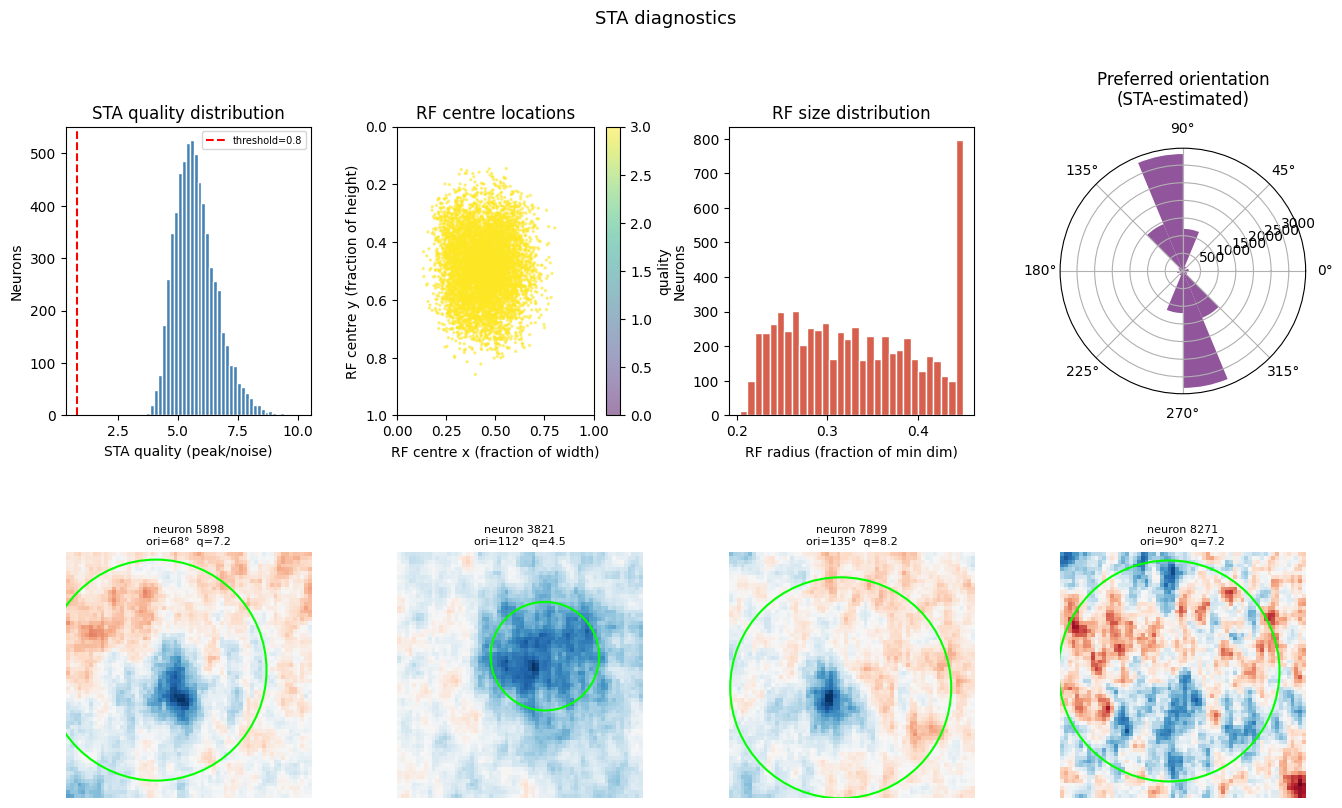

Figure saved to sta_diagnostics.png


In [19]:
fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

# ── 1. STA quality histogram ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.hist(qualities, bins=40, color='steelblue', edgecolor='white')
ax.axvline(MIN_STA_QUALITY, color='red', linestyle='--', label=f'threshold={MIN_STA_QUALITY}')
ax.set_xlabel('STA quality (peak/noise)')
ax.set_ylabel('Neurons')
ax.set_title('STA quality distribution')
ax.legend(fontsize=7)

# ── 2. RF centre scatter ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
xs = [v['rf_x_frac'] for v in neuron_tuning.values()]
ys = [v['rf_y_frac'] for v in neuron_tuning.values()]
qs = [v['quality']   for v in neuron_tuning.values()]
sc = ax.scatter(xs, ys, c=qs, cmap='viridis', s=2, alpha=0.5, vmin=0, vmax=3)
plt.colorbar(sc, ax=ax, label='quality')
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)   # y=0 is top of screen
ax.set_xlabel('RF centre x (fraction of width)')
ax.set_ylabel('RF centre y (fraction of height)')
ax.set_title('RF centre locations')

# ── 3. RF size histogram ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
rs = [v['rf_size_frac'] for v in neuron_tuning.values()]
ax.hist(rs, bins=30, color='#d6604d', edgecolor='white')
ax.set_xlabel('RF radius (fraction of min dim)')
ax.set_ylabel('Neurons')
ax.set_title('RF size distribution')

# ── 4. Preferred orientation histogram ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 3], polar=True)
oris = [v['pref_ori'] for v in neuron_tuning.values()]
bins_rad = np.linspace(0, np.pi, N_ORI + 1)
counts, _ = np.histogram(np.deg2rad(oris), bins=bins_rad)
# Mirror for 180° periodicity
theta = (bins_rad[:-1] + bins_rad[1:]) / 2
ax.bar(np.concatenate([theta, theta + np.pi]), np.tile(counts, 2),
       width=np.pi/N_ORI, color='#762a83', alpha=0.8)
ax.set_title('Preferred orientation\n(STA-estimated)', pad=12)

# ── 5-8. Example STAs ────────────────────────────────────────────────────────
trusted_keys = [
    k for k, v in neuron_tuning.items()
    if v['quality'] >= MIN_STA_QUALITY and v['sta_img'] is not None
]
sample_keys = trusted_keys[:4] if len(trusted_keys) >= 4 else trusted_keys

for col, nkey in enumerate(sample_keys):
    ax  = fig.add_subplot(gs[1, col])
    tun = neuron_tuning[nkey]
    ax.imshow(tun['sta_img'], cmap='RdBu_r', origin='upper',
              vmin=-np.abs(tun['sta_img']).max(),
              vmax= np.abs(tun['sta_img']).max())
    # Draw estimated RF
    cy  = tun['rf_y_frac'] * STA_SIZE
    cx  = tun['rf_x_frac'] * STA_SIZE
    cr  = tun['rf_size_frac'] * STA_SIZE
    circ = plt.Circle((cx, cy), cr, fill=False, color='lime', linewidth=1.5)
    ax.add_patch(circ)
    ax.set_title(
        f'neuron {nkey}\nori={tun["pref_ori"]:.0f}°  q={tun["quality"]:.1f}',
        fontsize=8
    )
    ax.axis('off')

fig.suptitle('STA diagnostics', fontsize=13, y=1.01)
plt.savefig('sta_diagnostics.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved to sta_diagnostics.png')

## New feature extraction functions

Both functions operate on the **64×64 downsampled clip** already in cache.

In [20]:
def extract_rf_local_channels(clip_64, rf_y_frac, rf_x_frac, rf_size_frac, target_len):
    """
    3 channels computed only inside the estimated RF patch:
      [0] rf_luminance  — mean pixel intensity per frame
      [1] rf_contrast   — pixel std per frame
      [2] rf_motion     — absolute frame-to-frame difference

    Returns (3, target_len), each channel z-scored.
    """
    out = np.zeros((3, target_len), dtype=np.float32)
    if clip_64 is None:
        return out

    F, H, W = clip_64.shape
    rf_y    = int(rf_y_frac * H)
    rf_x    = int(rf_x_frac * W)
    rf_r    = max(int(rf_size_frac * min(H, W)), 2)
    y0, y1  = max(0, rf_y - rf_r), min(H, rf_y + rf_r)
    x0, x1  = max(0, rf_x - rf_r), min(W, rf_x + rf_r)

    patch = clip_64[:, y0:y1, x0:x1].astype(np.float32)  # (F, h, w)
    if patch.size == 0:
        return out

    pix  = patch.reshape(F, -1)
    lum  = pix.mean(axis=1)                       # (F,)
    con  = pix.std(axis=1)                        # (F,)
    if F > 1:
        mot = np.concatenate([[0.],
              np.abs(np.diff(patch, axis=0)).reshape(F-1, -1).mean(axis=1)])
    else:
        mot = np.zeros(F, dtype=np.float32)

    for i, sig in enumerate([lum, con, mot]):
        out[i] = zscore_1d(resample_to(sig, target_len))
    return out


def extract_gabor_channels(clip_64, rf_y_frac, rf_x_frac, rf_size_frac,
                           pref_ori_deg, sf_cpx, target_len):
    """
    2 channels: Gabor energy at preferred and orthogonal orientation,
    computed inside the RF patch, vectorised over all frames.

      [0] gabor_preferred  — energy at pref_ori_deg
      [1] gabor_orthogonal — energy at pref_ori_deg + 90°

    Returns (2, target_len), each channel z-scored.
    """
    out = np.zeros((2, target_len), dtype=np.float32)
    if clip_64 is None:
        return out

    F, H, W = clip_64.shape
    rf_y    = int(rf_y_frac * H)
    rf_x    = int(rf_x_frac * W)
    rf_r    = max(int(rf_size_frac * min(H, W)), 4)
    y0, y1  = max(0, rf_y - rf_r), min(H, rf_y + rf_r)
    x0, x1  = max(0, rf_x - rf_r), min(W, rf_x + rf_r)

    patch_seq = clip_64[:, y0:y1, x0:x1].astype(np.float32)  # (F, ph, pw)
    ph, pw    = patch_seq.shape[1], patch_seq.shape[2]
    if ph < 2 or pw < 2:
        return out

    size = min(ph, pw)
    p    = patch_seq[:, :size, :size]              # (F, size, size)

    # Build 4 filters (even/odd × preferred/orthogonal)
    even_p = _gabor_2d(size, pref_ori_deg,      sf_cpx, 0.0)
    odd_p  = _gabor_2d(size, pref_ori_deg,      sf_cpx, np.pi/2)
    even_o = _gabor_2d(size, pref_ori_deg + 90, sf_cpx, 0.0)
    odd_o  = _gabor_2d(size, pref_ori_deg + 90, sf_cpx, np.pi/2)

    # Vectorised dot product over all F frames
    e_p = (p * even_p).sum(axis=(1, 2))           # (F,)
    o_p = (p * odd_p ).sum(axis=(1, 2))
    e_o = (p * even_o).sum(axis=(1, 2))
    o_o = (p * odd_o ).sum(axis=(1, 2))

    energy_pref = np.sqrt(e_p**2 + o_p**2)
    energy_orth = np.sqrt(e_o**2 + o_o**2)

    out[0] = zscore_1d(resample_to(energy_pref, target_len))
    out[1] = zscore_1d(resample_to(energy_orth, target_len))
    return out


print('Feature extraction functions defined.')

Feature extraction functions defined.


## Build 17-channel dataset

In [21]:
records = []
skipped = 0

for nkey, snap in first_snap.items():
    layer = snap['layer']
    clip_64 = clip_cache_64.get(snap['cond_hash'])
    tun     = neuron_tuning.get(nkey)

    if tun is None:
        skipped += 1
        continue

    # ── 3 RF-local channels ───────────────────────────────────────────────────
    rf_local = extract_rf_local_channels(
        clip_64,
        tun['rf_y_frac'], tun['rf_x_frac'], tun['rf_size_frac'],
        TARGET_LEN,
    )

    # ── 2 Gabor channels ─────────────────────────────────────────────────────
    gabor_ch = extract_gabor_channels(
        clip_64,
        tun['rf_y_frac'], tun['rf_x_frac'], tun['rf_size_frac'],
        tun['pref_ori'], PREF_SF_CPX,
        TARGET_LEN,
    )

    # ── Assemble 17-channel tensor ────────────────────────────────────────────
    multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
    multichan[0]     = snap['trace_z']                                   # neural
    if snap['global_stim'] is not None:
        multichan[1:8]  = snap['global_stim']                            # global stim
    multichan[8:11]  = rf_local                                          # RF-local
    multichan[11:13] = gabor_ch                                          # Gabor
    if snap['beh'] is not None:
        multichan[13:17] = snap['beh']                                   # behaviour

    records.append({
        'neuron_key': nkey,
        'layer':      layer,
        'multichan':  multichan,
        'unit_id':    snap['unit_id'],
        'sta_quality':tun['quality'],
    })

print(f'Dataset records built: {len(records)}  (skipped: {skipped})')
print('Samples by layer:')
print(pd.Series([r['layer'] for r in records]).value_counts().sort_index())

Dataset records built: 6548  (skipped: 0)
Samples by layer:
L2/3    2704
L4      2072
L5      1425
L6       347
Name: count, dtype: int64


## Train / test split

In [22]:
neuron_df = pd.DataFrame(
    [{'neuron_key': r['neuron_key'], 'layer': r['layer']} for r in records]
).drop_duplicates(subset=['neuron_key'])

layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)].copy()

TARGET_TRAIN = 6000
test_size    = 0.25
total_target = int(round(TARGET_TRAIN / (1 - test_size)))
if len(neuron_df) > total_target:
    _, neuron_df = train_test_split(
        neuron_df, train_size=total_target, random_state=42,
        stratify=neuron_df['layer'].values,
    )
    neuron_df = neuron_df.reset_index(drop=True)

train_keys, test_keys = train_test_split(
    neuron_df['neuron_key'].values, test_size=test_size,
    random_state=42, stratify=neuron_df['layer'].values,
)
train_set, test_set = set(train_keys), set(test_keys)

enc = LabelEncoder()
enc.fit(neuron_df['layer'])

def build_split(keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in keys_set or r['layer'] not in keep_layers:
            continue
        X.append(r['multichan'])
        y.append(r['layer'])
        uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)

X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {enc.classes_}')

Train: (4911, 17, 300)  |  Test: (1637, 17, 300)
Classes: ['L2/3' 'L4' 'L5' 'L6']


## Model definition and training

In [23]:
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
    ])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

BATCH_SIZE = 128

def make_loader(X, y, shuffle):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False,
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

PyTorch 2.11.0+cpu | device: cpu
Train batches: 39  |  Test batches: 13


In [32]:
class MultiChannelShallowCNN(nn.Module):
    """
    Same architecture as CNN_multichannel.ipynb — three 1-D conv blocks
    followed by a dense head.  In_channels is now 17 instead of 12.

    Block 1: Conv1d(C → 64,  k=7) → BN → ReLU → MaxPool(2)
    Block 2: Conv1d(64→ 128, k=5) → BN → ReLU → MaxPool(2)
    Block 3: Conv1d(128→256, k=3) → BN → ReLU → MaxPool(2)
    Head   : Flatten → Linear(256·T/8, 256) → ReLU → Dropout → Linear
    """
    def __init__(self, in_channels, seq_len, n_classes, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=7, padding=3),
            nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(64,        128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,       256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * (seq_len // 8), 256), nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.conv(x))


def train_model(model, train_loader, test_loader,
                lr=3e-4, weight_decay=1e-4, max_epochs=150, patience=100):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

    history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_loss, best_state, patience_cnt = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)
        scheduler.step()

        history['train_loss'].append(
            sum(criterion(model(xb.to(DEVICE)),
                          yb.to(DEVICE)).item()
                for xb, yb in train_loader) / len(train_loader)
        ) if False else None  # skip recompute for speed — only log val
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d} | val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stop at epoch {epoch}')
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'Restored best checkpoint  val_loss={best_loss:.4f}')
    return history


model = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Input shape: (batch, {N_CHANNELS}, {TARGET_LEN})')

Parameters: 2,574,340
Input shape: (batch, 17, 300)


In [33]:
history = train_model(model, train_loader, test_loader)

Epoch   1 | val_loss=1.1251  val_acc=0.362
Epoch   2 | val_loss=1.0884  val_acc=0.377
Epoch   3 | val_loss=1.0760  val_acc=0.374
Epoch   4 | val_loss=1.0892  val_acc=0.375
Epoch   5 | val_loss=1.1149  val_acc=0.376
Epoch   6 | val_loss=1.0677  val_acc=0.393
Epoch   7 | val_loss=1.0773  val_acc=0.432
Epoch   8 | val_loss=1.0899  val_acc=0.427
Epoch   9 | val_loss=1.0929  val_acc=0.409
Epoch  10 | val_loss=1.0850  val_acc=0.419
Epoch  11 | val_loss=1.1016  val_acc=0.403
Epoch  12 | val_loss=1.0923  val_acc=0.425
Epoch  13 | val_loss=1.1109  val_acc=0.464
Epoch  14 | val_loss=1.0653  val_acc=0.492
Epoch  15 | val_loss=1.0799  val_acc=0.517
Epoch  16 | val_loss=1.1248  val_acc=0.535
Epoch  17 | val_loss=1.1202  val_acc=0.544
Epoch  18 | val_loss=1.1093  val_acc=0.557
Epoch  19 | val_loss=1.1570  val_acc=0.597
Epoch  20 | val_loss=1.2362  val_acc=0.604
Epoch  21 | val_loss=1.2202  val_acc=0.624
Epoch  22 | val_loss=1.2981  val_acc=0.625
Epoch  23 | val_loss=1.1165  val_acc=0.632
Epoch  24 |

## Evaluation

In [34]:
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
y_pred = np.concatenate(preds)

acc     = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mac_f1  = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy         : {acc:.3f}')
print(f'Balanced accuracy: {bal_acc:.3f}')
print(f'Macro F1         : {mac_f1:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=enc.classes_))

Accuracy         : 0.492
Balanced accuracy: 0.487
Macro F1         : 0.439

              precision    recall  f1-score   support

        L2/3       0.62      0.49      0.54       676
          L4       0.55      0.61      0.58       518
          L5       0.41      0.32      0.36       356
          L6       0.18      0.53      0.27        87

    accuracy                           0.49      1637
   macro avg       0.44      0.49      0.44      1637
weighted avg       0.53      0.49      0.50      1637



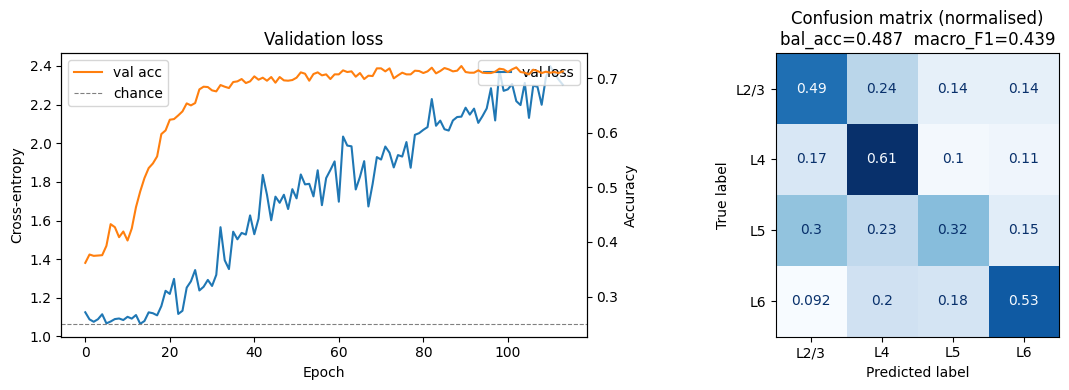

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training curve
ax = axes[0]
ax.plot(history['val_loss'], label='val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy')
ax.set_title('Validation loss')
ax2 = ax.twinx()
ax2.plot(history['val_acc'], color='tab:orange', label='val acc')
ax2.set_ylabel('Accuracy')
ax2.axhline(1/n_classes, color='grey', linestyle='--', linewidth=0.8, label='chance')
ax.legend(loc='upper right')
ax2.legend(loc='upper left')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=enc.classes_,
    normalize='true',
    cmap='Blues',
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title(f'Confusion matrix (normalised)\nbal_acc={bal_acc:.3f}  macro_F1={mac_f1:.3f}')

plt.tight_layout()
plt.show()

## Comparison with baseline

                        model  channels  accuracy  balanced_acc  macro_f1
  ShallowCNN 12-ch (baseline)        12  0.814000      0.818000  0.771000
ShallowCNN 17-ch (RF + Gabor)        17  0.492364      0.486684  0.438834


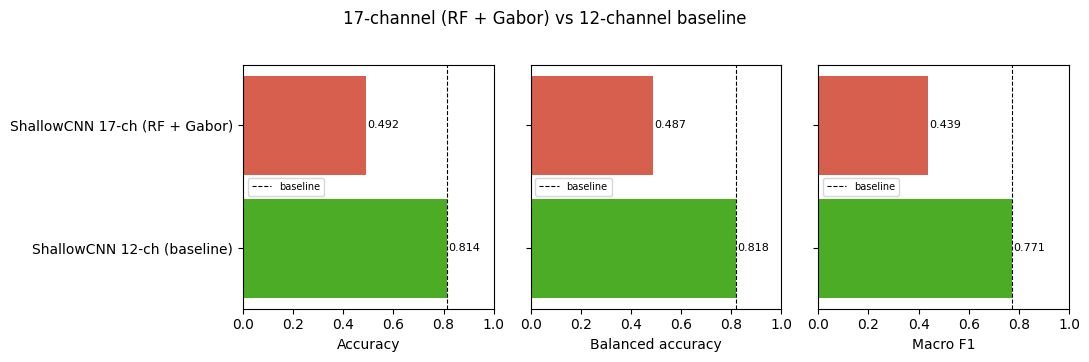

In [36]:
comparison = pd.DataFrame([
    # Baseline numbers from CNN_multichannel.ipynb (12-channel ShallowCNN)
    {'model': 'ShallowCNN 12-ch (baseline)',
     'channels': 12, 'accuracy': 0.814, 'balanced_acc': 0.818, 'macro_f1': 0.771},
    # This notebook
    {'model': 'ShallowCNN 17-ch (RF + Gabor)',
     'channels': N_CHANNELS, 'accuracy': acc, 'balanced_acc': bal_acc, 'macro_f1': mac_f1},
])
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
metrics   = ['accuracy', 'balanced_acc', 'macro_f1']
titles    = ['Accuracy', 'Balanced accuracy', 'Macro F1']
colors    = ['#4dac26', '#d6604d']
for ax, metric, title in zip(axes, metrics, titles):
    ax.barh(comparison['model'], comparison[metric], color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel(title)
    ax.axvline(comparison[metric].iloc[0], color='black',
               linestyle='--', linewidth=0.8, label='baseline')
    for i, v in enumerate(comparison[metric]):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('17-channel (RF + Gabor) vs 12-channel baseline', y=1.02)
plt.tight_layout()
plt.show()

## Discussion

### What the new channels add

| Channel group | Signal | Layer-discriminative mechanism |
|---|---|---|
| `rf_luminance / rf_contrast / rf_motion` | Stimulus drive **at the actual RF location** | Layer-specific contrast sensitivity (L4 highest); local motion selectivity differs L4 vs L5 |
| `gabor_preferred` | How well the visual drive aligns to the neuron's preferred orientation | If the neuron is strongly driven by a preferred grating ↔ STA-predicted, that coupling shape carries layer info |
| `gabor_orthogonal` | Drive at the orthogonal orientation | The ratio `preferred / orthogonal` encodes orientation selectivity — known to differ by layer |

### Limitations of STA-based estimation

- **Natural movies are not white noise**: the STA is biased by stimulus statistics. A regularised reverse correlation (e.g., kernel ridge regression) would give a less biased RF, but requires more trials.
- **Calcium imaging is slow**: the indicator dynamics blur the STA in time. The lag correction (`STA_LAG = 1`) is a coarse approximation; deconvolution would help.
- **64×64 spatial resolution**: fine enough to localise RFs but too coarse to resolve sub-RF structure or accurately compute high-SF Gabor energy. Increasing `STA_SIZE` to 128+ (at the cost of more RAM) would sharpen both.
- **Fixed spatial frequency**: `PREF_SF_CPX = 0.06` cycles/pixel is a population-median guess. Fitting the SF from a 2-D Gabor to the STA, or scanning a multi-scale bank, would improve the Gabor energy estimate.

### Next steps

- Run `channel_importance.ipynb` on this 17-channel model to check which new channels actually contribute.
- Try replacing global stim channels 1–7 with RF-local versions only (removing global information) to test whether locality is what matters.
- Explore whether neurons with high STA quality classify better — if so, `quality` itself may be a useful meta-feature.